# EDA 

`train_2016_2017_union.csv` + `stores` + `transactions` + `items` + `holidays_events` + `oil`, con `store_nbr == 44`

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
CARPETA_BASE = "C:/Tesis"
TAMANO_MUESTRA_GRAFICO = 100_000   # solo para gráficos de dispersión (muchos puntos = ilegible)
SEMILLA_ALEATORIA = 42 # "semilla" para los procesos aleatorios.

In [3]:
# Paleta de colores para el notebook
COLOR_PRINCIPAL = "#4C72B0"      # azul — series únicas (histogramas, líneas, barras simples)
COLOR_SECUNDARIO = "#DD8452"     # naranja — para comparaciones de 2 grupos
PALETA_CATEGORICA = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
"#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]
MAPA_SECUENCIAL = "Blues"        # para el heatmap de correlaciones

# guarda la configuración por defecto en los gráficos del notebook
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})


## 1. Carga de datos

In [4]:
RUTA = os.path.join(CARPETA_BASE, "bbdd_filtrada.csv")

In [5]:
# Declaración de tipos de datos 
TIPOS_DATOS = {
    "id": "int64",
    "store_nbr": "int16",
    "item_nbr": "int32",
    "unit_sales": "float32",
    "cluster": "Int16",
    "class": "Int32",
    "perishable": "Int8",
    "transactions": "Int32",
}


In [6]:
df = pd.read_csv(RUTA, dtype=TIPOS_DATOS, parse_dates=["date"])
print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")

C:\Users\Laury\AppData\Local\Temp\ipykernel_12680\960815179.py:1: DtypeWarning: Columns (0: holiday_type, 1: locale, 2: locale_name, 3: description, 4: transferred) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RUTA, dtype=TIPOS_DATOS, parse_dates=["date"])


Filas: 1,599,702
Columnas: 20


## 2. Vista general

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1599702 entries, 0 to 1599701
Data columns (total 20 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   id            1599702 non-null  int64         
 1   date          1599702 non-null  datetime64[us]
 2   store_nbr     1599702 non-null  int16         
 3   item_nbr      1599702 non-null  int32         
 4   unit_sales    1599702 non-null  float32       
 5   onpromotion   1599702 non-null  bool          
 6   city          1599702 non-null  str           
 7   state         1599702 non-null  str           
 8   store_type    1599702 non-null  str           
 9   cluster       1599702 non-null  Int16         
 10  transactions  1594596 non-null  Int32         
 11  family        1599702 non-null  str           
 12  class         1599702 non-null  Int32         
 13  perishable    1599702 non-null  Int8          
 14  holiday_type  266285 non-null   str           
 15  locale   

In [8]:
df.head(10)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,city,state,store_type,cluster,transactions,family,class,perishable,holiday_type,locale,locale_name,description,transferred,dcoilwtico
0,66538108,2016-01-02,44,103520,8.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1028,0,NaN,NaN,NaN,NaN,NaN,NaN
1,66538109,2016-01-02,44,103665,11.0,False,Quito,Pichincha,A,5,4539,BREAD/BAKERY,2712,1,NaN,NaN,NaN,NaN,NaN,NaN
2,66538110,2016-01-02,44,105574,22.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1045,0,NaN,NaN,NaN,NaN,NaN,NaN
3,66538111,2016-01-02,44,105575,47.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1045,0,NaN,NaN,NaN,NaN,NaN,NaN
4,66538112,2016-01-02,44,105577,1.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1045,0,NaN,NaN,NaN,NaN,NaN,NaN
5,66538113,2016-01-02,44,105693,4.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1034,0,NaN,NaN,NaN,NaN,NaN,NaN
6,66538114,2016-01-02,44,105737,32.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1044,0,NaN,NaN,NaN,NaN,NaN,NaN
7,66538115,2016-01-02,44,105857,24.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1092,0,NaN,NaN,NaN,NaN,NaN,NaN
8,66538116,2016-01-02,44,106716,9.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1032,0,NaN,NaN,NaN,NaN,NaN,NaN
9,66538117,2016-01-02,44,108634,38.0,False,Quito,Pichincha,A,5,4539,GROCERY I,1075,0,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df['date'].min(), df['date'].max()

(Timestamp('2016-01-02 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [43]:
print("onpromotion:")
print(df["onpromotion"].value_counts(dropna=False))

print("\nperishable:")
print(df["perishable"].value_counts(dropna=False))

print("\ntransferred:")
print(df["transferred"].value_counts(dropna=False))

onpromotion:
onpromotion
False    1449330
True      150372
Name: count, dtype: int64

perishable:
perishable
0    1167248
1     432454
Name: count, dtype: Int64

transferred:
transferred
NaN      1333417
False     250498
True       15787
Name: count, dtype: int64


In [68]:
categoricas = ["family", "city", "state", "store_type", "holiday_type", "locale", "locale_name", "description"]

for col in categoricas:
    print(f"\n{col} — {df[col].nunique()} categorías distintas:")
    print(df[col].value_counts(dropna=False).head(10))


family — 32 categorías distintas:
family
GROCERY I        527210
BEVERAGES        243800
CLEANING         180488
PRODUCE          130852
DAIRY            116425
BREAD/BAKERY      57304
PERSONAL CARE     57283
HOME CARE         44627
DELI              41010
MEATS             30519
Name: count, dtype: int64

city — 1 categorías distintas:
city
Quito    1599702
Name: count, dtype: int64

state — 1 categorías distintas:
state
Pichincha    1599702
Name: count, dtype: int64

store_type — 1 categorías distintas:
store_type
A    1599702
Name: count, dtype: int64

holiday_type — 5 categorías distintas:
holiday_type
NaN           1333417
Holiday        134289
Event           78374
Additional      33853
Transfer        16955
Bridge           2814
Name: count, dtype: int64

locale — 3 categorías distintas:
locale
NaN         1333417
National     156739
Local         95327
Regional      14219
Name: count, dtype: int64

locale_name — 22 categorías distintas:
locale_name
NaN          1333417
Ecuador

In [72]:
categoricas = ["class", "cluster"]

for col in categoricas:
    print(f"\n{col} — {df[col].nunique()} categorías distintas:")
    print(df[col].value_counts(dropna=False).head(10))


class — 324 categorías distintas:
class
1016    50196
1040    47939
1124    41257
1034    36676
1072    32381
1122    31857
1032    27854
3020    26328
1120    26174
1148    22620
Name: count, dtype: Int64

cluster — 1 categorías distintas:
cluster
5    1599702
Name: count, dtype: Int64


In [49]:
print("Rango de fechas:", df["date"].min().date(), "->", df["date"].max().date())
print("Tiendas presentes:", df["store_nbr"].unique())
print("Productos distintos:", f"{df['item_nbr'].nunique():,}")
print(f"Memoria usada: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")


Rango de fechas: 2016-01-02 -> 2017-08-15
Tiendas presentes: [44]
Productos distintos: 3,656
Memoria usada: 686.0 MB


## 3. Valores nulos
Es esperable ver nulos en `dcoilwtico` (el petróleo no se transa fines de semana/feriados), en las columnas de `holidays_events` (la mayoría de los días no son feriado) y en `onpromotion` (no todas las filas lo indican). Nulos en otras columnas sí ameritan revisión.

In [50]:
nulos = df.isna().sum()
nulos_pct = (df.isna().mean() * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje": nulos_pct}).sort_values("nulos", ascending=False)
resumen_nulos


,nulos,porcentaje
holiday_type,1333417,83.35
transferred,1333417,83.35
locale,1333417,83.35
locale_name,1333417,83.35
description,1333417,83.35
dcoilwtico,516119,32.26
transactions,5106,0.32
unit_sales,0,0.00
date,0,0.00
id,0,0.00


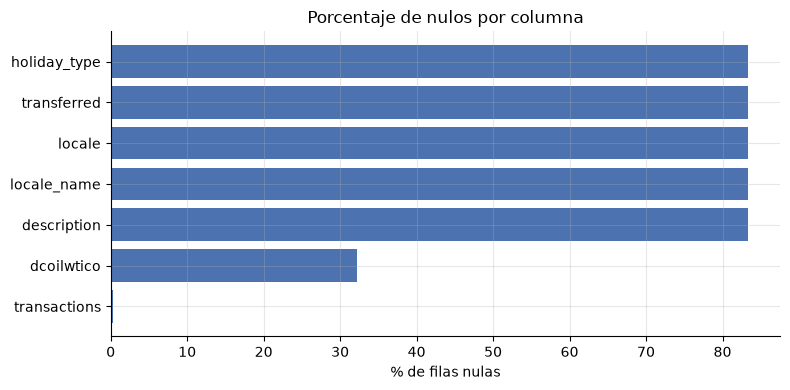

In [51]:
con_nulos = resumen_nulos[resumen_nulos["nulos"] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(con_nulos.index[::-1], con_nulos["porcentaje"][::-1], color=COLOR_PRINCIPAL)
ax.set_xlabel("% de filas nulas")
ax.set_title("Porcentaje de nulos por columna")
plt.tight_layout()
plt.show()


## 4. Duplicados

In [52]:
dup_id = df["id"].duplicated().sum()
dup_combo = df.duplicated(subset=["store_nbr", "item_nbr", "date"]).sum()

print("Filas con id duplicado:", dup_id)
print("Filas con combinación (tienda, producto, fecha) duplicada:", dup_combo)


Filas con id duplicado: 0
Filas con combinación (tienda, producto, fecha) duplicada: 0


## 5. Estadísticas descriptivas — variables numéricas

In [53]:
df[["unit_sales", "transactions", "dcoilwtico", "class", "cluster"]].describe().round(0)


,unit_sales,transactions,dcoilwtico,class,cluster
count,1599702.0,1594596.0,1083583.0,1599702.0,1599702.0
mean,17.0,4384.0,46.0,2041.0,5.0
std,38.0,700.0,6.0,1276.0,0.0
min,-363.0,3018.0,26.0,1002.0,5.0
25%,3.0,3842.0,44.0,1064.0,5.0
50%,8.0,4239.0,47.0,2004.0,5.0
75%,17.0,4835.0,50.0,2712.0,5.0
max,3556.0,8307.0,54.0,7780.0,5.0


## 6. Variables categóricas
`store_type` y `cluster` deberían salir con un solo valor (es una sola tienda)

In [54]:
print("store_type:", df["store_type"].unique())
print("cluster:", df["cluster"].unique())
print("city:", df["city"].unique())
print("state:", df["state"].unique())


store_type: <StringArray>
['A']
Length: 1, dtype: str
cluster: <IntegerArray>
[5]
Length: 1, dtype: Int16
city: <StringArray>
['Quito']
Length: 1, dtype: str
state: <StringArray>
['Pichincha']
Length: 1, dtype: str


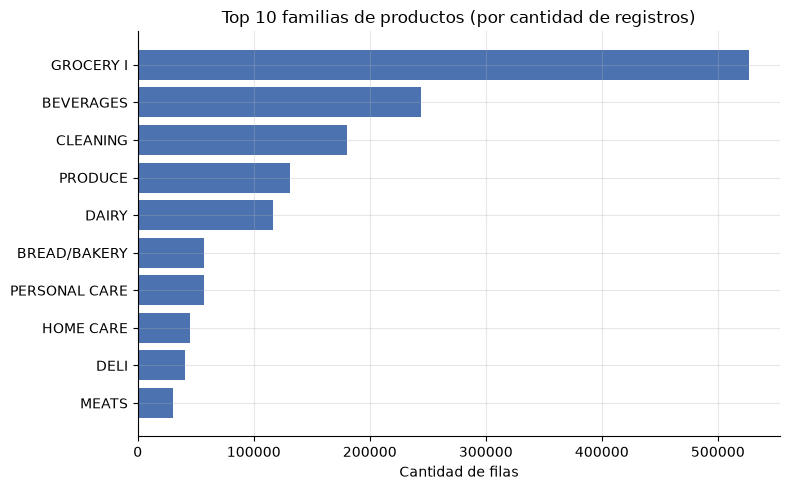

In [55]:
top_familias = df["family"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_familias.index[::-1], top_familias.values[::-1], color=COLOR_PRINCIPAL)
ax.set_xlabel("Cantidad de filas")
ax.set_title("Top 10 familias de productos (por cantidad de registros)")
plt.tight_layout()
plt.show()


In [56]:
print("onpromotion:")
print(df["onpromotion"].value_counts(dropna=False))
print()
print("perishable:")
print(df["perishable"].value_counts(dropna=False))
print()
print("holiday_type (solo días feriado, el resto es NaN):")
print(df["holiday_type"].value_counts(dropna=False))


onpromotion:
onpromotion
False    1449330
True      150372
Name: count, dtype: int64

perishable:
perishable
0    1167248
1     432454
Name: count, dtype: Int64

holiday_type (solo días feriado, el resto es NaN):
holiday_type
NaN           1333417
Holiday        134289
Event           78374
Additional      33853
Transfer        16955
Bridge           2814
Name: count, dtype: int64


## 7. Distribución de unit_sales

In [57]:
df["unit_sales"].describe().round()


count    1599702.0
mean          17.0
std           38.0
min         -363.0
25%            3.0
50%            8.0
75%           17.0
max         3556.0
Name: unit_sales, dtype: float64

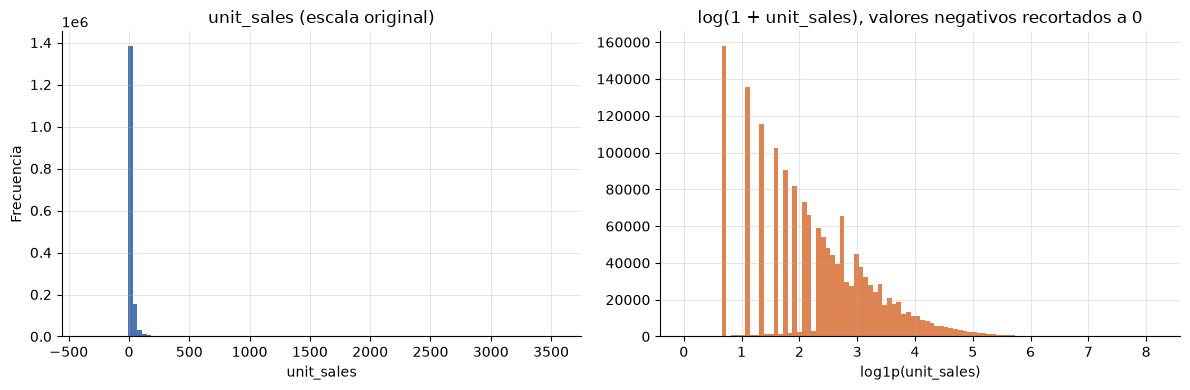

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["unit_sales"], bins=100, color=COLOR_PRINCIPAL)
axes[0].set_title("unit_sales (escala original)")
axes[0].set_xlabel("unit_sales")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["unit_sales"].clip(lower=0)), bins=100, color=COLOR_SECUNDARIO)
axes[1].set_title("log(1 + unit_sales), valores negativos recortados a 0")
axes[1].set_xlabel("log1p(unit_sales)")

plt.tight_layout()
plt.show()


C:\Users\Laury\AppData\Local\Temp\ipykernel_12680\2313183086.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df["unit_sales"], vert=True)


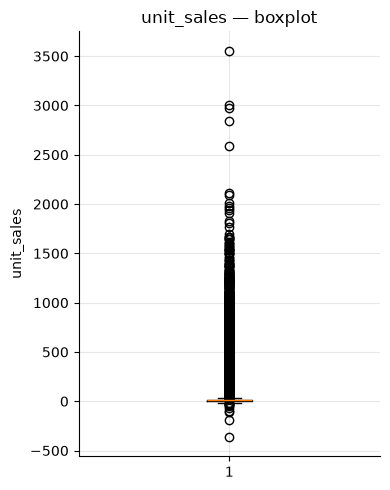

In [59]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(df["unit_sales"], vert=True)
ax.set_title("unit_sales — boxplot")
ax.set_ylabel("unit_sales")
plt.tight_layout()
plt.show()


In [60]:
q1 = df["unit_sales"].quantile(0.25)
q3 = df["unit_sales"].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = df[(df["unit_sales"] < limite_inf) | (df["unit_sales"] > limite_sup)]
negativos = df[df["unit_sales"] < 0]

print(f"Rango normal (IQR): [{limite_inf:.2f}, {limite_sup:.2f}]")
print(f"Filas fuera de ese rango (outliers): {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Filas con unit_sales negativo (devoluciones): {len(negativos):,} ({len(negativos)/len(df)*100:.2f}%)")


Rango normal (IQR): [-18.00, 38.00]
Filas fuera de ese rango (outliers): 142,271 (8.89%)
Filas con unit_sales negativo (devoluciones): 210 (0.01%)


## 8. Evolución temporal

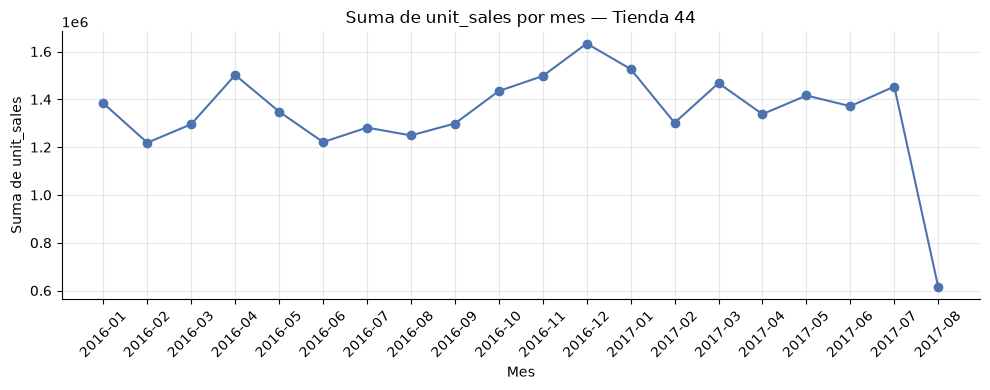

In [61]:
ventas_mensuales = df.groupby(df["date"].dt.to_period("M"))["unit_sales"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ventas_mensuales.index.astype(str), ventas_mensuales.values, marker="o", color=COLOR_PRINCIPAL)
ax.set_title("Suma de unit_sales por mes — Tienda 44")
ax.set_xlabel("Mes")
ax.set_ylabel("Suma de unit_sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


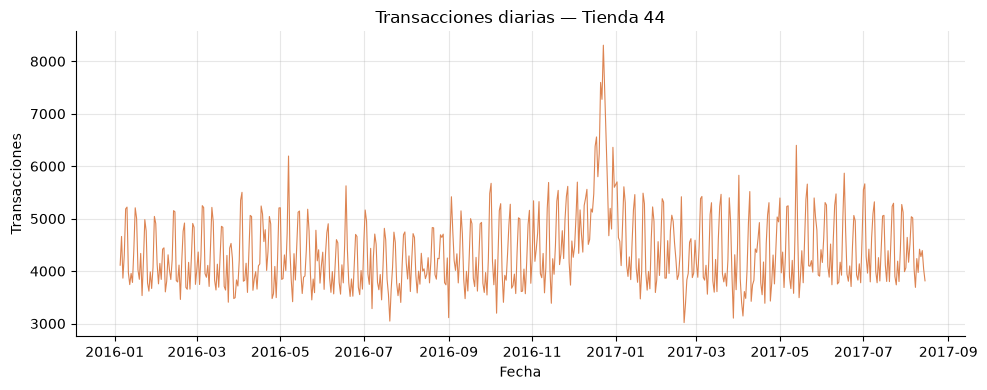

In [62]:
transacciones_diarias = df.drop_duplicates(subset="date")[["date", "transactions"]].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(transacciones_diarias["date"], transacciones_diarias["transactions"], color=COLOR_SECUNDARIO, linewidth=0.8)
ax.set_title("Transacciones diarias — Tienda 44")
ax.set_xlabel("Fecha")
ax.set_ylabel("Transacciones")
plt.tight_layout()
plt.show()


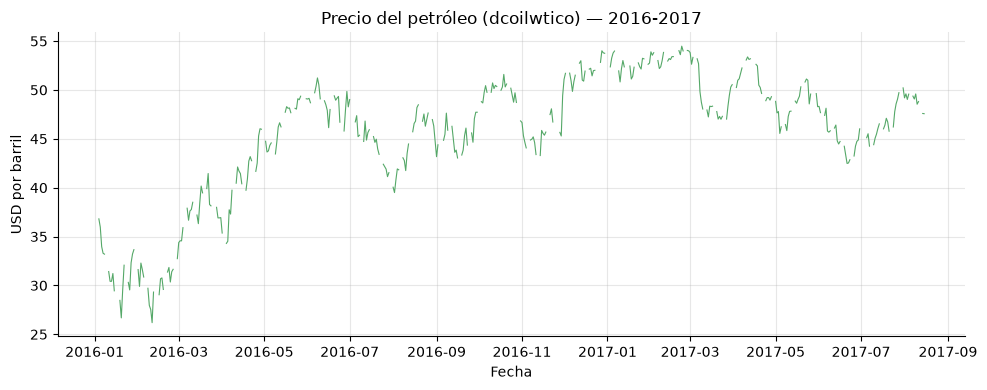

In [63]:
precio_petroleo = df.drop_duplicates(subset="date")[["date", "dcoilwtico"]].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(precio_petroleo["date"], precio_petroleo["dcoilwtico"], color="#55A868", linewidth=0.8)
ax.set_title("Precio del petróleo (dcoilwtico) — 2016-2017")
ax.set_xlabel("Fecha")
ax.set_ylabel("USD por barril")
plt.tight_layout()
plt.show()


## 9. Relación de las variables con unit_sales

### unit_sales promedio por familia de producto (top 10)

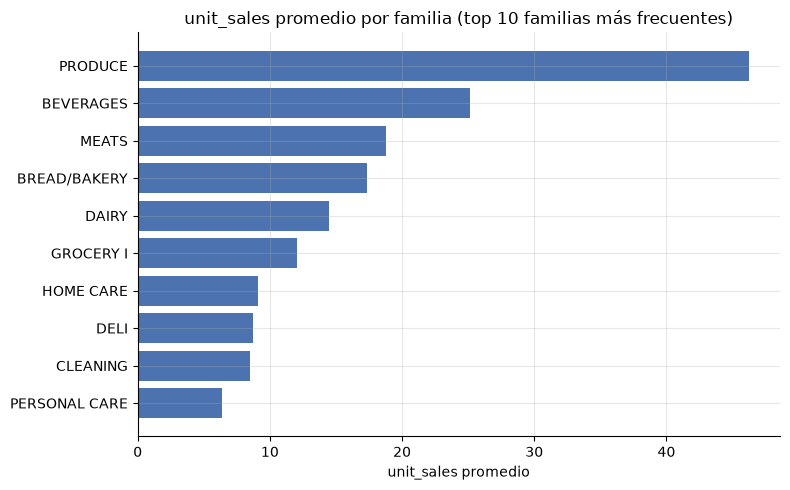

In [64]:
top10_familias = df["family"].value_counts().head(10).index
promedio_por_familia = (
    df[df["family"].isin(top10_familias)]
    .groupby("family")["unit_sales"].mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(promedio_por_familia.index[::-1], promedio_por_familia.values[::-1], color=COLOR_PRINCIPAL)
ax.set_xlabel("unit_sales promedio")
ax.set_title("unit_sales promedio por familia (top 10 familias más frecuentes)")
plt.tight_layout()
plt.show()


### unit_sales: en promoción vs. sin promoción

onpromotion
False    15.539549
True     28.819584
Name: unit_sales, dtype: float32


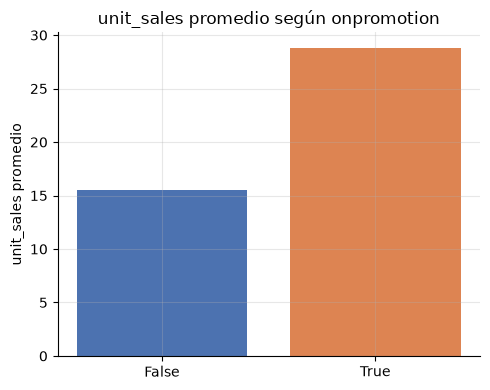

In [65]:
promedio_promocion = df.groupby(df["onpromotion"].fillna("Sin dato"))["unit_sales"].mean()
print(promedio_promocion)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(promedio_promocion.index.astype(str), promedio_promocion.values,
       color=[COLOR_PRINCIPAL, COLOR_SECUNDARIO, "#8C8C8C"][:len(promedio_promocion)])
ax.set_ylabel("unit_sales promedio")
ax.set_title("unit_sales promedio según onpromotion")
plt.tight_layout()
plt.show()


### unit_sales: días feriado vs. días normales
Ojo: esto marca como feriado cualquier día donde `holiday_type` no sea nulo, sin distinguir si el feriado era local de otra ciudad o si fue `transferred` (trasladado a otra fecha) — es una simplificación, no una regla perfecta de calendario.

es_feriado
False    16.549202
True     17.983017
Name: unit_sales, dtype: float32


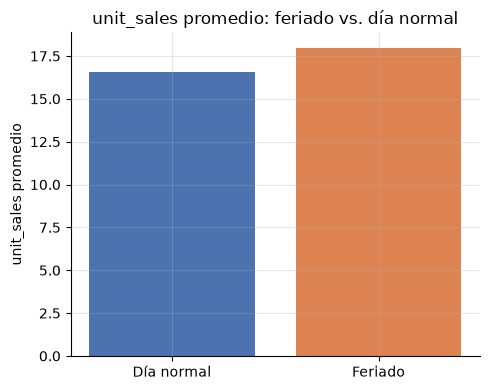

In [66]:
df["es_feriado"] = df["holiday_type"].notna()

promedio_feriado = df.groupby("es_feriado")["unit_sales"].mean()
print(promedio_feriado)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Día normal", "Feriado"], promedio_feriado.values, color=[COLOR_PRINCIPAL, COLOR_SECUNDARIO])
ax.set_ylabel("unit_sales promedio")
ax.set_title("unit_sales promedio: feriado vs. día normal")
plt.tight_layout()
plt.show()


### unit_sales vs. precio del petróleo
Con más de un millón de puntos el gráfico de dispersión queda ilegible, así que acá sí usamos una muestra aleatoria (`PLOT_SAMPLE_SIZE`) — solo para que el gráfico se vea bien, no para el cálculo de la correlación (esa sí es sobre el 100% de los datos).

Correlación unit_sales vs dcoilwtico (sobre el 100% de los datos): 0.0002


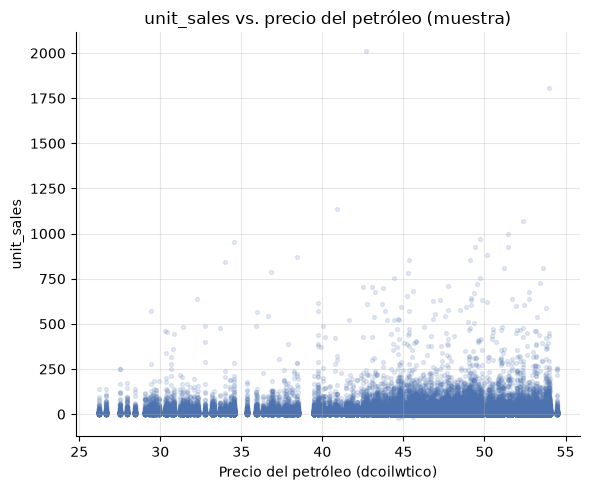

In [74]:
correlacion_oil = df[["unit_sales", "dcoilwtico"]].corr().iloc[0, 1]
print(f"Correlación unit_sales vs dcoilwtico (sobre el 100% de los datos): {correlacion_oil:.4f}")

muestra_plot = df.dropna(subset=["dcoilwtico"]).sample(min(TAMANO_MUESTRA_GRAFICO, df["dcoilwtico"].notna().sum()), random_state=SEMILLA_ALEATORIA)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(muestra_plot["dcoilwtico"], muestra_plot["unit_sales"], alpha=0.15, s=8, color=COLOR_PRINCIPAL)
ax.set_xlabel("Precio del petróleo (dcoilwtico)")
ax.set_ylabel("unit_sales")
ax.set_title("unit_sales vs. precio del petróleo (muestra)")
plt.tight_layout()
plt.show()


### unit_sales vs. transacciones de la tienda ese día

Correlación unit_sales vs transactions (sobre el 100% de los datos): 0.0908


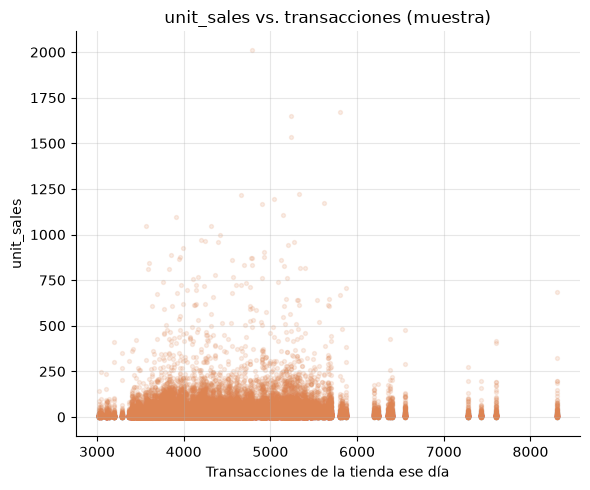

In [75]:
correlacion_trans = df[["unit_sales", "transactions"]].corr().iloc[0, 1]
print(f"Correlación unit_sales vs transactions (sobre el 100% de los datos): {correlacion_trans:.4f}")

muestra_plot2 = df.sample(min(TAMANO_MUESTRA_GRAFICO, len(df)), random_state=SEMILLA_ALEATORIA)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(muestra_plot2["transactions"], muestra_plot2["unit_sales"], alpha=0.15, s=8, color=COLOR_SECUNDARIO)
ax.set_xlabel("Transacciones de la tienda ese día")
ax.set_ylabel("unit_sales")
ax.set_title("unit_sales vs. transacciones (muestra)")
plt.tight_layout()
plt.show()


### Matriz de correlaciones (variables numéricas)

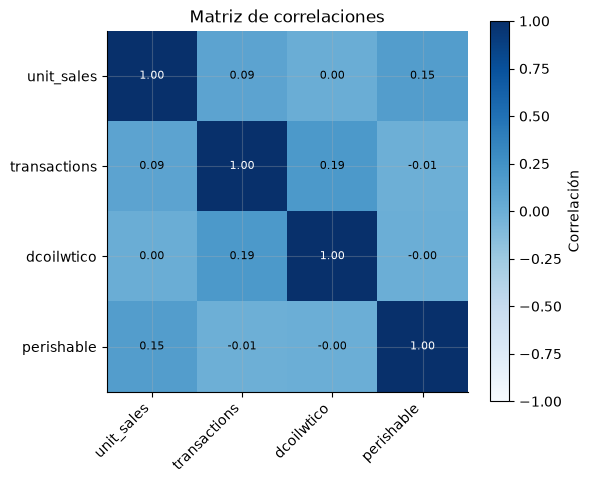

In [77]:
numericas = df[["unit_sales", "transactions", "dcoilwtico", "perishable"]]
corr = numericas.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap=MAPA_SECUENCIAL, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlación")
ax.set_title("Matriz de correlaciones")
plt.tight_layout()
plt.show()


## 10. Resumen ejecutivo
Un resumen numérico de todo lo anterior, útil para pegarlo directo en la tesis (sección de resultados del EDA).

In [78]:
print("===== RESUMEN EDA — bbdd_filtrada (Tienda 44, 2016-2017) =====")
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print(f"Rango de fechas: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Productos distintos: {df['item_nbr'].nunique():,}")
print(f"IDs duplicados: {dup_id} | Combinaciones duplicadas: {dup_combo}")
print()
print(f"unit_sales -> media: {df['unit_sales'].mean():.2f} | mediana: {df['unit_sales'].median():.2f} | "
      f"std: {df['unit_sales'].std():.2f} | min: {df['unit_sales'].min():.2f} | max: {df['unit_sales'].max():.2f}")
print(f"% de filas con unit_sales negativo (devoluciones): {len(negativos)/len(df)*100:.2f}%")
print(f"% de filas outlier (regla IQR): {len(outliers)/len(df)*100:.2f}%")
print()
print(f"unit_sales promedio EN promoción: {promedio_promocion.get(True, float('nan')):.2f}")
print(f"unit_sales promedio SIN promoción: {promedio_promocion.get(False, float('nan')):.2f}")
print(f"unit_sales promedio en FERIADO: {promedio_feriado.get(True, float('nan')):.2f}")
print(f"unit_sales promedio en día normal: {promedio_feriado.get(False, float('nan')):.2f}")
print()
print(f"Correlación unit_sales - dcoilwtico: {correlacion_oil:.4f}")
print(f"Correlación unit_sales - transactions: {correlacion_trans:.4f}")
print(f"Familia con mayor unit_sales promedio (top 10 más frecuentes): {promedio_por_familia.index[0]}")


===== RESUMEN EDA — bbdd_filtrada (Tienda 44, 2016-2017) =====
Filas: 1,599,702 | Columnas: 21
Rango de fechas: 2016-01-02 -> 2017-08-15
Productos distintos: 3,656
IDs duplicados: 0 | Combinaciones duplicadas: 0

unit_sales -> media: 16.79 | mediana: 8.00 | std: 37.50 | min: -363.00 | max: 3556.00
% de filas con unit_sales negativo (devoluciones): 0.01%
% de filas outlier (regla IQR): 8.89%

unit_sales promedio EN promoción: 28.82
unit_sales promedio SIN promoción: 15.54
unit_sales promedio en FERIADO: 17.98
unit_sales promedio en día normal: 16.55

Correlación unit_sales - dcoilwtico: 0.0002
Correlación unit_sales - transactions: 0.0908
Familia con mayor unit_sales promedio (top 10 más frecuentes): PRODUCE


 - El marcado de `es_feriado` es una simplificación (no distingue feriados locales de otra ciudad ni `transferred`) — defínelo con más detalle si tu análisis lo necesita.